In [1]:
import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.basegenerators import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric

from utils.basegenerators import BenchmarkGenerator, ReprosynGenerator, Raw
from reprosyn.methods import DS_PRIVBAYES
from utils.tapas.tapas_data_processors import AdultDataProcessor

estimating categorical probs
estimating approx kdes(histogram)
[0.6772666961521451]
Attacking : Raw
Generated datasest of Raw stored at :data/generated_datasets/Raw.pkl
COMPLEXITY:  2
COMPLEXITY:  20


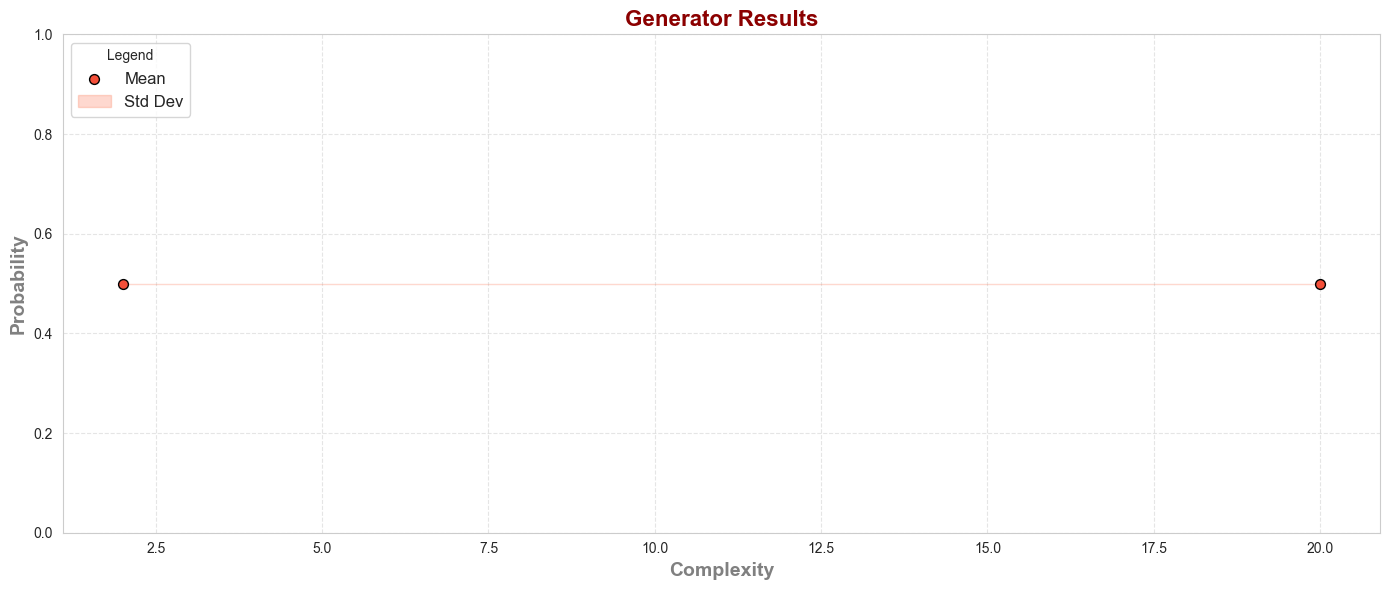

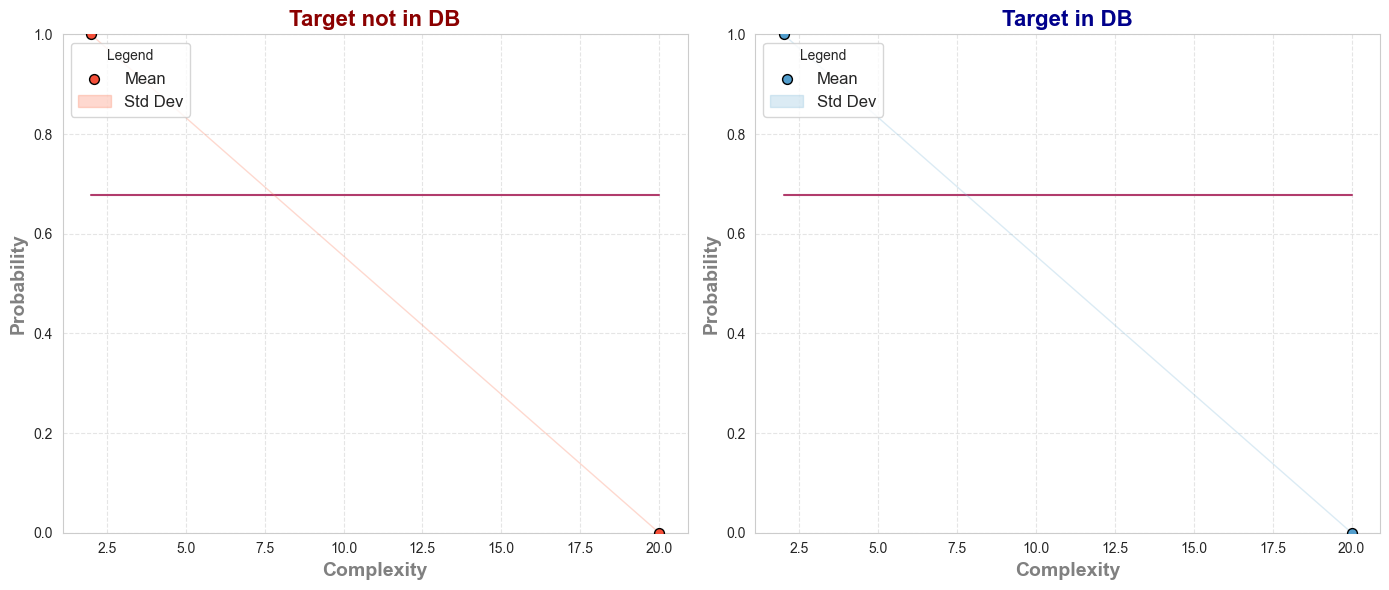

Attacking : PrivBayes_epsilon=1.0
Generated datasest of PrivBayes stored at :data/generated_datasets/PrivBayes_epsilon=1.0.pkl
COMPLEXITY:  2
COMPLEXITY:  20


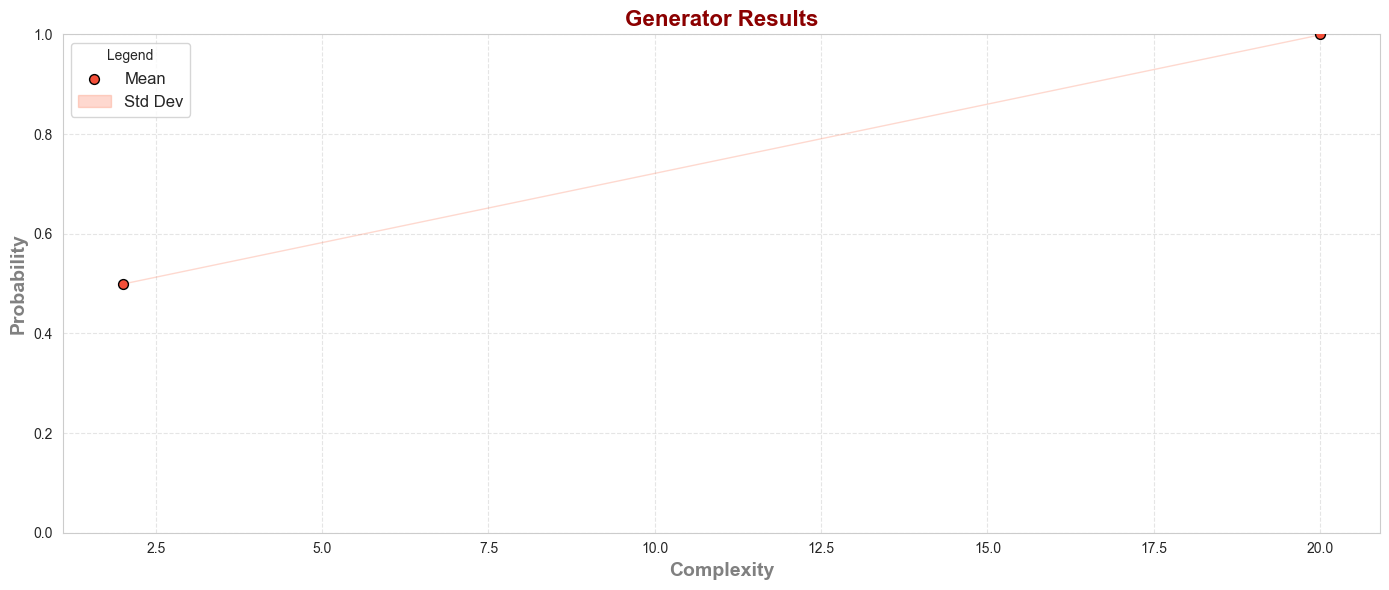

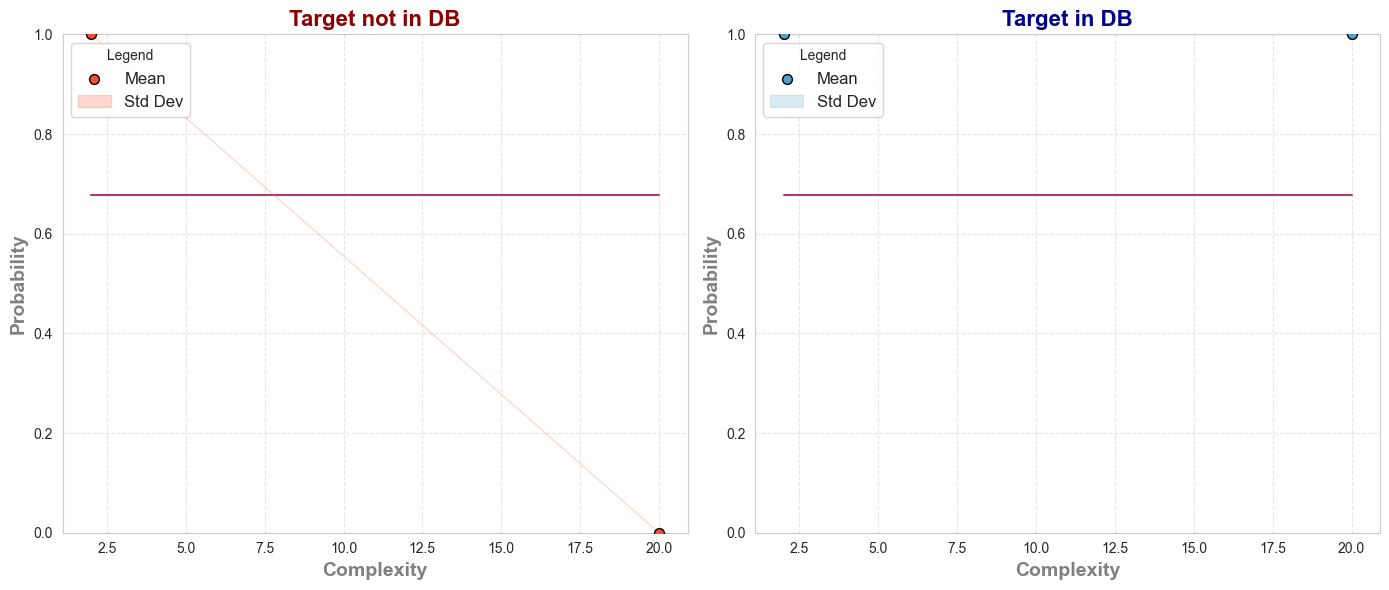

----[Benchmark ranks]----
Raw : D, 0.5
Raw was not broken by the attack
PrivBayes : E, 0.75
Generators Metrics saved to results/2025_05_20_22_15/generators_metrics.csv
Attack results saved to results/2025_05_20_22_15/attack_results.yaml


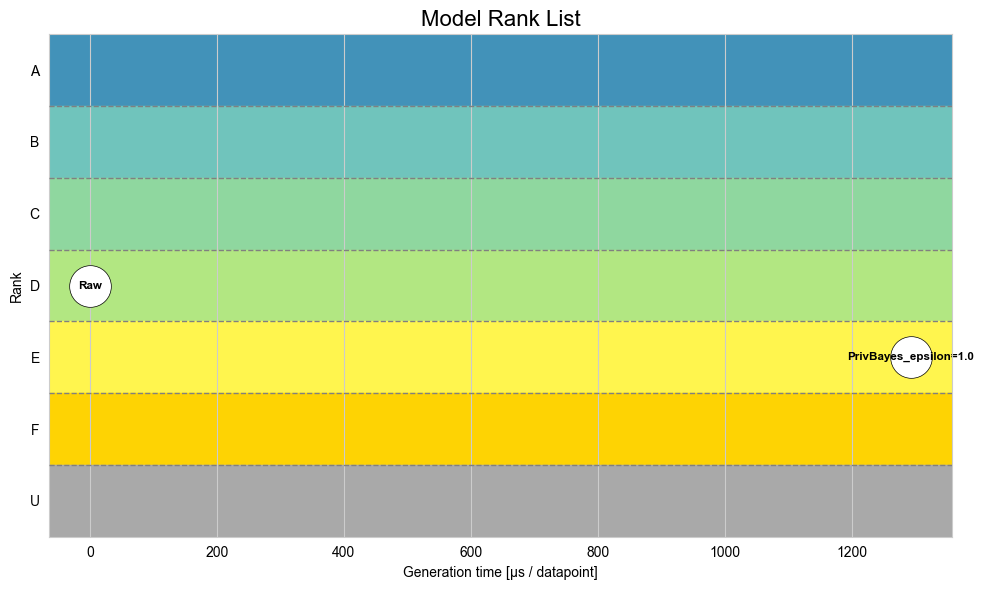

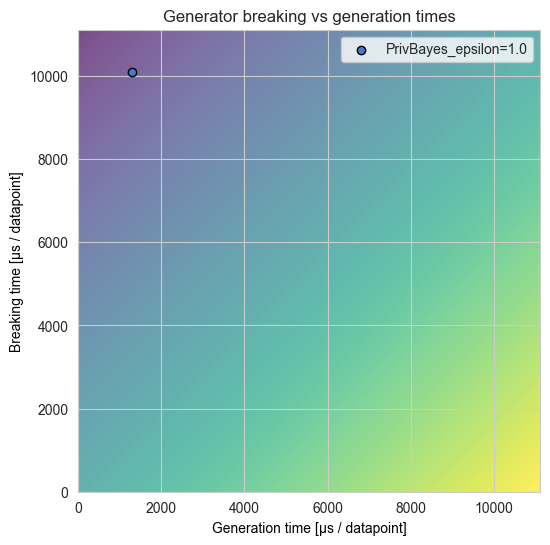

Evaluating original data
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Evaluating : Raw
Evaluating generated data
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Evaluating : PrivBayes_epsilon=1.0
Evaluating generated data
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Results saved to results/2025_05_20_22_15/results_ml_utility.csv
Evaluating : Raw
Evaluating : PrivBayes_epsilon=1.0


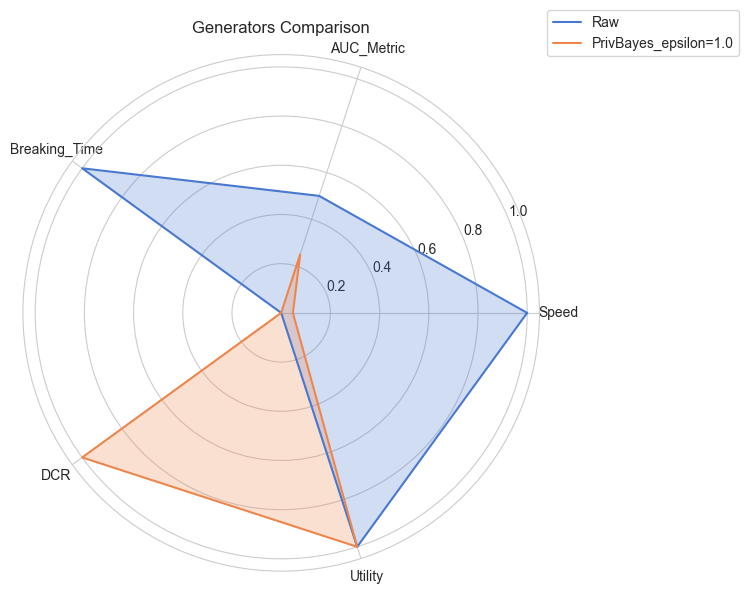

In [2]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,3,2))

gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

pipeline = BenchmarkPipeline(data, attack, [Raw(), gen], target_record=target_record)
benchmarking_metric = AUCMetric()


# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
pipeline.run([2,20], 1, 2,  plot_style='all', benchmarking_metric=benchmarking_metric, 
classification_target_col="income", dcr_metric="gower", generate_data=True)